In [2]:
%pip install pandas
%pip install seaborn
%pip install matplotlib

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 9.8 MB/s eta 0:00:01
   -------------- ------------------------- 3.7/9.9 MB 11.2 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 10.4 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 11.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.7 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.3 MB 2.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.3 MB 2.6 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 2.8 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 2.9 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 2.9 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 3.0 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 3.0 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.3 MB 3.0 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 2.9 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 2.9 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 2.8 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('embedded_system_network_security_dataset.csv')
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [9]:
# Focusing on only a feq columns
df = df[['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'label', 'mean_packet_size']]

In [10]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   packet_size         1000 non-null   float64
 1   inter_arrival_time  1000 non-null   float64
 2   src_port            1000 non-null   int64  
 3   dst_port            1000 non-null   int64  
 4   label               1000 non-null   float64
 5   mean_packet_size    1000 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 47.0 KB
packet_size           0
inter_arrival_time    0
src_port              0
dst_port              0
label                 0
mean_packet_size      0
dtype: int64


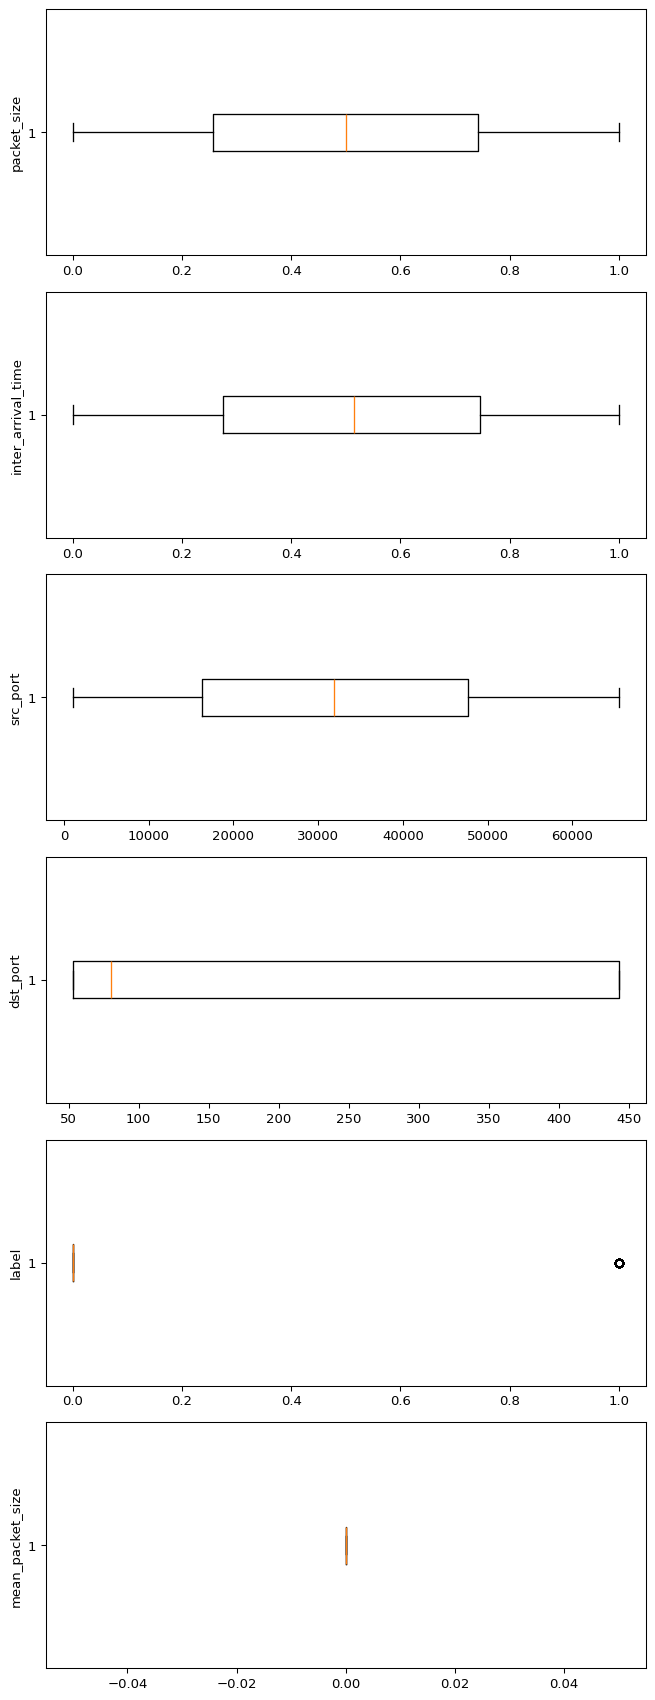

In [11]:
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
# from scapy.all import get_if_list

# print(get_if_list())

['\\Device\\NPF_{6D115F62-13AC-4FBA-BC7C-B81AF197287B}', '\\Device\\NPF_{9073DBFB-6910-4415-BFC3-AB0CD581F594}', '\\Device\\NPF_{50CD40B8-A908-412D-8865-CA62D707159A}', '\\Device\\NPF_{C39EDA06-B2B5-4901-B5C7-4E743543A5E2}', '\\Device\\NPF_{2DF86585-9867-415D-A77C-DAEEA72944A8}', '\\Device\\NPF_{8DAA72C4-E1CB-4DDA-989E-8EEAC123D30C}', '\\Device\\NPF_{5184F4CF-4CA7-4389-B8C4-74F0BB2A7E43}', '\\Device\\NPF_Loopback', '\\Device\\NPF_{8B8DC57A-B7D6-46D9-A536-05793CCA3DF7}']


In [ ]:
# from scapy.all import *

# iface = "\\Device\\NPF_Loopback"

# packet = IP(dst="127.0.0.1")/TCP(dport=8080)/Raw(load="TEST IDS")

# send(packet, iface=iface)


Sent 1 packets.


In [ ]:
# from scapy.all import *

# def packet_callback(pkt):
#     print(pkt.summary())

# sniff(iface=iface, prn=packet_callback, store=0)

Loopback / IP / TCP 127.0.0.1:50999 > 127.0.0.1:50998 PA / Raw
Loopback / IP / TCP 127.0.0.1:50998 > 127.0.0.1:50999 A
Loopback / IP / TCP 127.0.0.1:50999 > 127.0.0.1:50998 PA / Raw
Loopback / IP / TCP 127.0.0.1:50998 > 127.0.0.1:50999 A
Loopback / IP / TCP 127.0.0.1:61703 > 127.0.0.1:61702 PA / Raw
Loopback / IP / TCP 127.0.0.1:61702 > 127.0.0.1:61703 A
Loopback / IP / TCP 127.0.0.1:61703 > 127.0.0.1:61702 PA / Raw
Loopback / IP / TCP 127.0.0.1:61702 > 127.0.0.1:61703 A
Loopback / IP / TCP 127.0.0.1:61679 > 127.0.0.1:61678 PA / Raw
Loopback / IP / TCP 127.0.0.1:61678 > 127.0.0.1:61679 A
Loopback / IP / TCP 127.0.0.1:9028 > 127.0.0.1:61714 PA / Raw
Loopback / IP / TCP 127.0.0.1:61714 > 127.0.0.1:9028 A
Loopback / IP / TCP 127.0.0.1:61679 > 127.0.0.1:61678 PA / Raw
Loopback / IP / TCP 127.0.0.1:61678 > 127.0.0.1:61679 A
Loopback / IP / TCP 127.0.0.1:9028 > 127.0.0.1:61714 PA / Raw
Loopback / IP / TCP 127.0.0.1:61714 > 127.0.0.1:9028 A
Loopback / IP / TCP 127.0.0.1:61703 > 127.0.0.1:6170

<Sniffed: TCP:0 UDP:0 ICMP:0 Other:0>